<a href="https://www.kaggle.com/code/omborse771924/2026-world-cup-analysis-features-engineering?scriptVersionId=338883426" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/troubador/2026-world-cup-player-statistics/wcplayerstatistics.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/troubador/2026-world-cup-player-statistics/wcplayerstatistics.csv')

In [3]:
df.head()

,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,PK,PKatt,CrdY,CrdR,PlayerID,AstPer90,G+APer90,GlsPer90,G-PKPer90,G+A-PKPer90
0,1,Brenden Aaronson,MF,us United States,25.0,1.eng Leeds United,2000.0,1.0,1.0,76.0,...,0.0,0.0,0.0,0.0,5bc43860,0.0,0.0,0.0,0.0,0.0
1,2,Thelo Aasgaard,MF,no Norway,24.0,1.sct Rangers,2002.0,1.0,1.0,90.0,...,0.0,0.0,0.0,0.0,c88a28b9,0.0,1.0,1.0,1.0,1.0
2,3,Hamza Abdelkarim,FW,eg Egypt,18.0,4.es Barcelona B,2008.0,4.0,0.0,60.0,...,0.0,0.0,0.0,0.0,057d8f12,0.0,0.0,0.0,0.0,0.0
3,4,Hossam Abdelmaguid,DF,eg Egypt,25.0,1.eg Zamalek SC,2001.0,2.0,0.0,59.0,...,0.0,0.0,0.0,0.0,accbfc94,0.0,0.0,0.0,0.0,0.0
4,5,Mohamed Abdelmonem,DF,eg Egypt,27.0,1.fr Nice,1999.0,2.0,1.0,14.0,...,0.0,0.0,0.0,0.0,bff15d74,0.0,0.0,0.0,0.0,0.0


In [4]:
df.tail()

,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,PK,PKatt,CrdY,CrdR,PlayerID,AstPer90,G+APer90,GlsPer90,G-PKPer90,G+A-PKPer90
1034,1035,Zizo,MF,eg Egypt,30.0,1.eg Al Ahly,1996.0,4.0,0.0,56.0,...,0.0,0.0,0.0,0.0,c6415ba9,0.00,0.00,0.00,0.00,0.00
1035,1036,Martín Zubimendi,MF,es Spain,27.0,1.eng Arsenal,1999.0,1.0,0.0,22.0,...,0.0,0.0,0.0,0.0,3ee0dd59,0.00,0.00,0.00,0.00,0.00
1036,1037,Themba Zwane,FWMF,za South Africa,36.0,1.za Sundowns,1989.0,1.0,0.0,23.0,...,0.0,0.0,0.0,1.0,c6f21aa8,0.00,0.00,0.00,0.00,0.00
1037,1038,Martin Ødegaard,MF,no Norway,27.0,1.eng Arsenal,1998.0,5.0,5.0,470.0,...,0.0,0.0,0.0,0.0,79300479,0.77,0.77,0.00,0.00,0.77
1038,1039,Leo Østigård,DF,no Norway,26.0,1.it Genoa,1999.0,5.0,1.0,146.0,...,0.0,0.0,0.0,0.0,b35a7399,0.00,0.62,0.62,0.62,0.62


In [5]:
df.info

<bound method DataFrame.info of         Rk              Player   Pos             Squad   Age  \
0        1    Brenden Aaronson    MF  us United States  25.0   
1        2      Thelo Aasgaard    MF         no Norway  24.0   
2        3    Hamza Abdelkarim    FW          eg Egypt  18.0   
3        4  Hossam Abdelmaguid    DF          eg Egypt  25.0   
4        5  Mohamed Abdelmonem    DF          eg Egypt  27.0   
...    ...                 ...   ...               ...   ...   
1034  1035                Zizo    MF          eg Egypt  30.0   
1035  1036    Martín Zubimendi    MF          es Spain  27.0   
1036  1037        Themba Zwane  FWMF   za South Africa  36.0   
1037  1038     Martin Ødegaard    MF         no Norway  27.0   
1038  1039        Leo Østigård    DF         no Norway  26.0   

                    Club    Born   MP  Starts    Min  ...   PK  PKatt  CrdY  \
0     1.eng Leeds United  2000.0  1.0     1.0   76.0  ...  0.0    0.0   0.0   
1          1.sct Rangers  2002.0  1.0    

In [6]:
df.isnull

<bound method DataFrame.isnull of         Rk              Player   Pos             Squad   Age  \
0        1    Brenden Aaronson    MF  us United States  25.0   
1        2      Thelo Aasgaard    MF         no Norway  24.0   
2        3    Hamza Abdelkarim    FW          eg Egypt  18.0   
3        4  Hossam Abdelmaguid    DF          eg Egypt  25.0   
4        5  Mohamed Abdelmonem    DF          eg Egypt  27.0   
...    ...                 ...   ...               ...   ...   
1034  1035                Zizo    MF          eg Egypt  30.0   
1035  1036    Martín Zubimendi    MF          es Spain  27.0   
1036  1037        Themba Zwane  FWMF   za South Africa  36.0   
1037  1038     Martin Ødegaard    MF         no Norway  27.0   
1038  1039        Leo Østigård    DF         no Norway  26.0   

                    Club    Born   MP  Starts    Min  ...   PK  PKatt  CrdY  \
0     1.eng Leeds United  2000.0  1.0     1.0   76.0  ...  0.0    0.0   0.0   
1          1.sct Rangers  2002.0  1.0  

In [7]:
df.isnull().sum()

Rk             0
Player         0
Pos            0
Squad          0
Age            0
Club           3
Born           0
MP             0
Starts         0
Min            0
90s            0
Gls            0
Ast            0
G+A            0
G-PK           0
PK             0
PKatt          0
CrdY           0
CrdR           0
PlayerID       0
AstPer90       0
G+APer90       0
GlsPer90       0
G-PKPer90      0
G+A-PKPer90    0
dtype: int64

In [8]:
# Fill missing values with the most frequent club
df['Club'] = df['Club'].fillna(df['Club'].mode()[0])

# Verify
print(df.isnull().sum())

Rk             0
Player         0
Pos            0
Squad          0
Age            0
Club           0
Born           0
MP             0
Starts         0
Min            0
90s            0
Gls            0
Ast            0
G+A            0
G-PK           0
PK             0
PKatt          0
CrdY           0
CrdR           0
PlayerID       0
AstPer90       0
G+APer90       0
GlsPer90       0
G-PKPer90      0
G+A-PKPer90    0
dtype: int64


In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1034    False
1035    False
1036    False
1037    False
1038    False
Length: 1039, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Club', 'Born', 'MP', 'Starts',
       'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY',
       'CrdR', 'PlayerID', 'AstPer90', 'G+APer90', 'GlsPer90', 'G-PKPer90',
       'G+A-PKPer90'],
      dtype='object')

## EDA

DATASET SHAPE
(1039, 25)


DATA TYPES
Rk               int64
Player          object
Pos             object
Squad           object
Age            float64
Club            object
Born           float64
MP             float64
Starts         float64
Min            float64
90s            float64
Gls            float64
Ast            float64
G+A            float64
G-PK           float64
PK             float64
PKatt          float64
CrdY           float64
CrdR           float64
PlayerID        object
AstPer90       float64
G+APer90       float64
GlsPer90       float64
G-PKPer90      float64
G+A-PKPer90    float64
dtype: object


MISSING VALUES
Rk             0
Player         0
Pos            0
Squad          0
Age            0
Club           0
Born           0
MP             0
Starts         0
Min            0
90s            0
Gls            0
Ast            0
G+A            0
G-PK           0
PK             0
PKatt          0
CrdY           0
CrdR           0
PlayerID       0
AstPer90       0

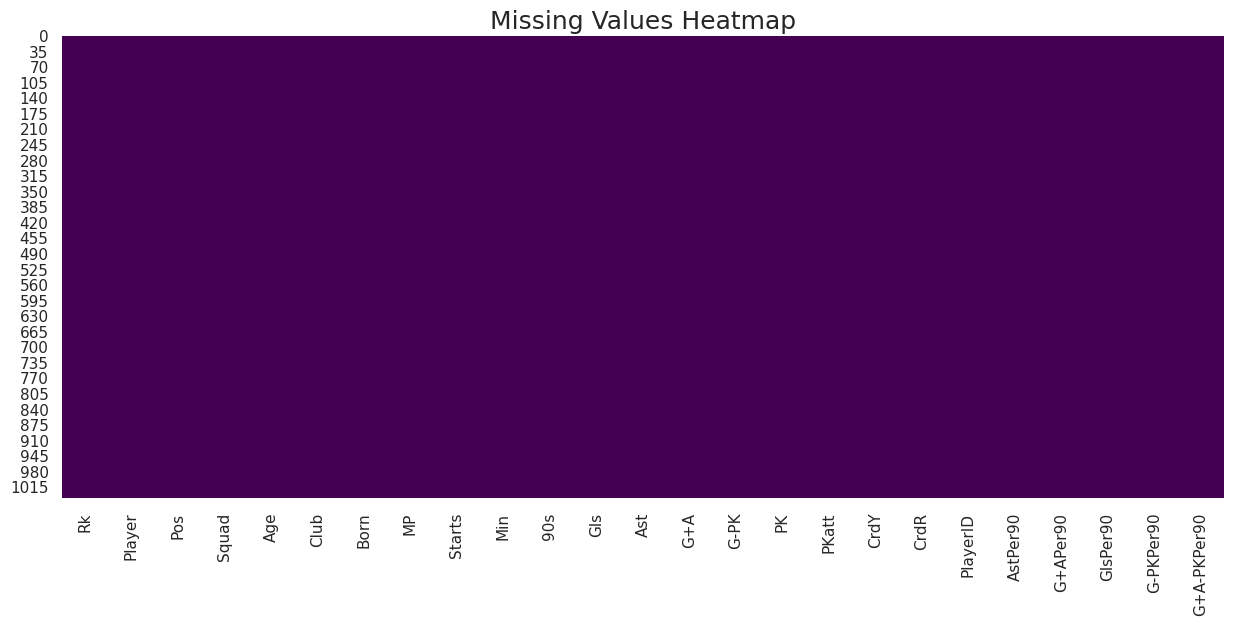

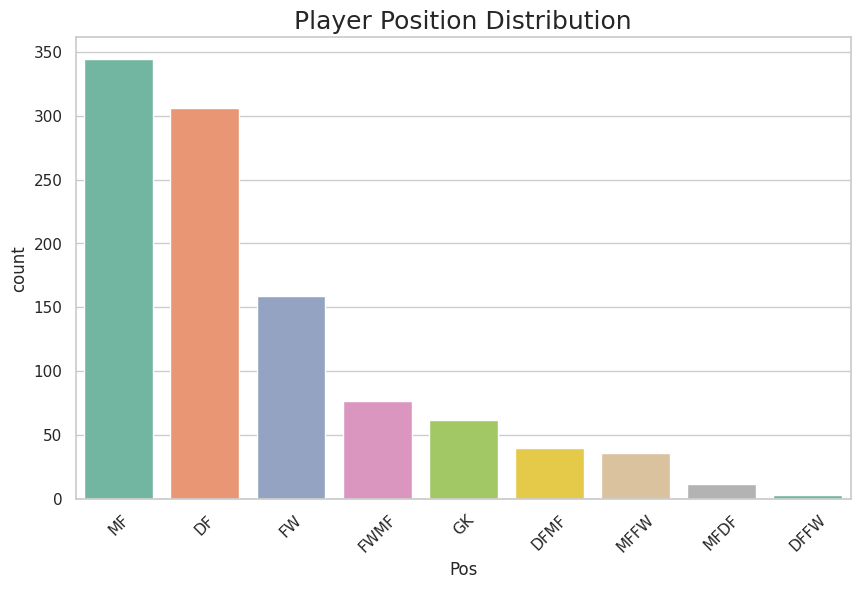

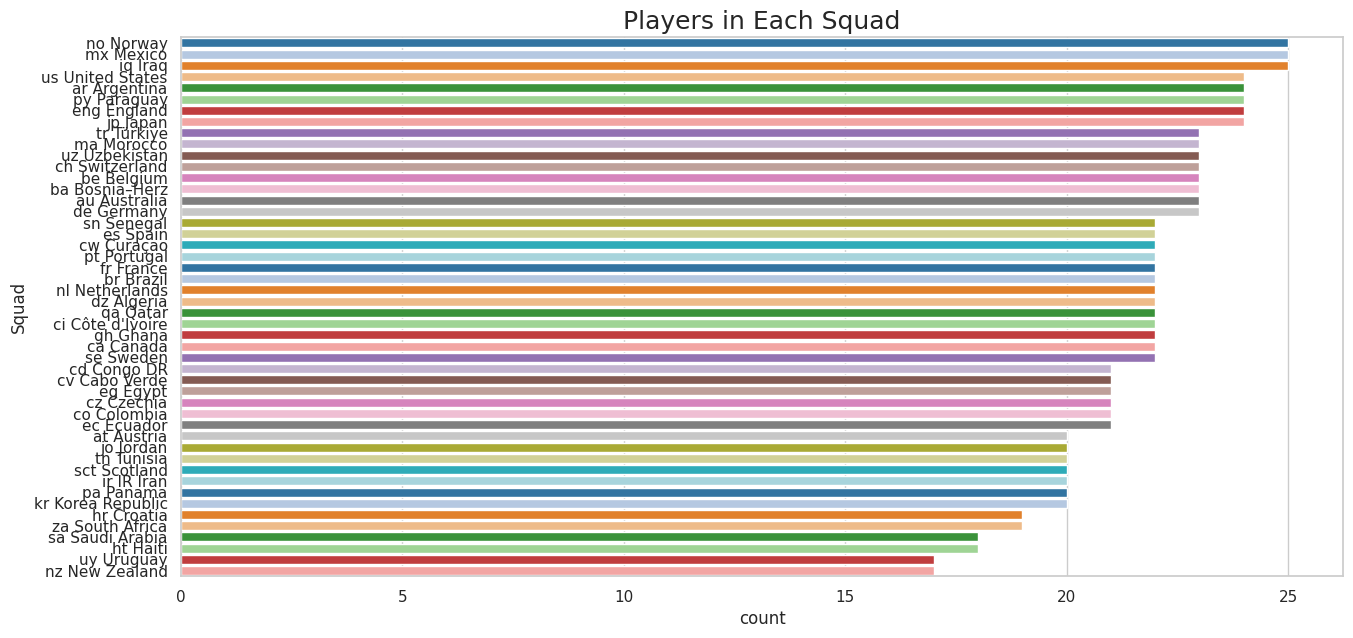

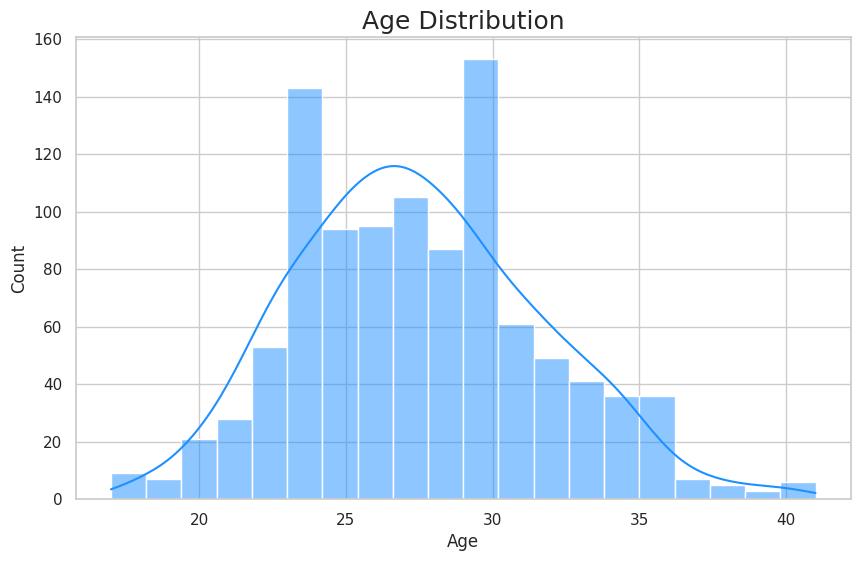

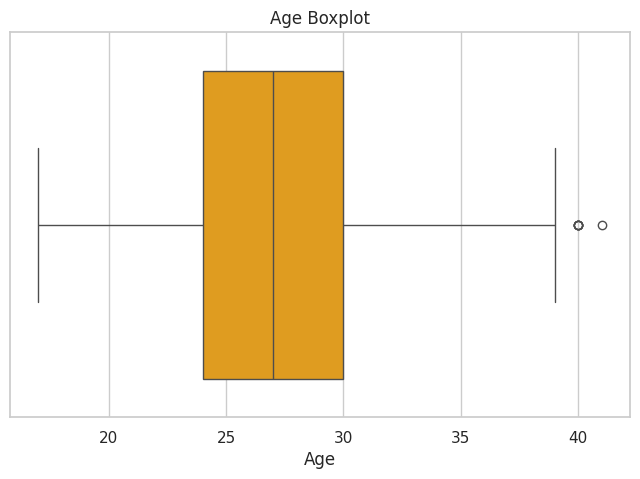

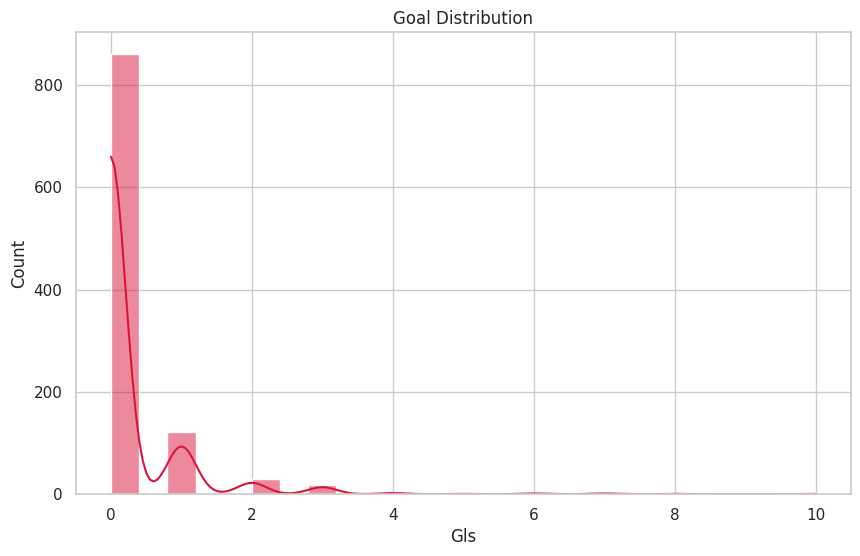

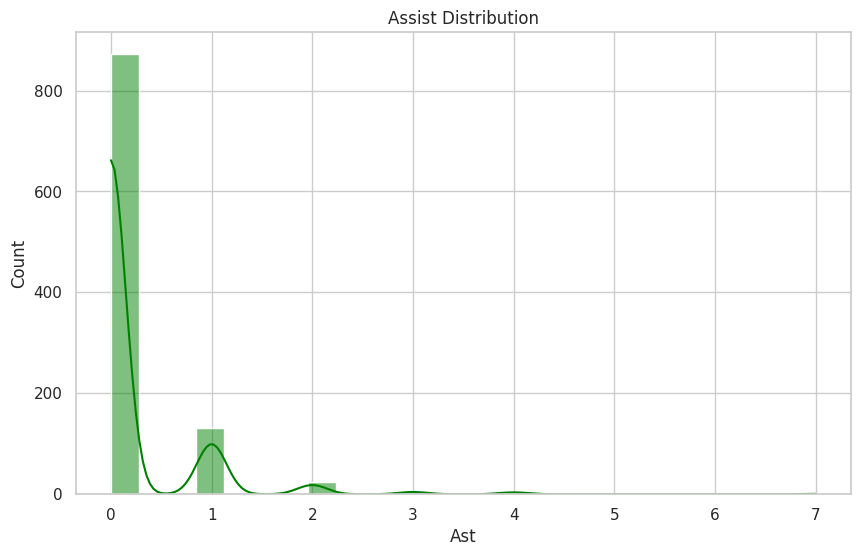

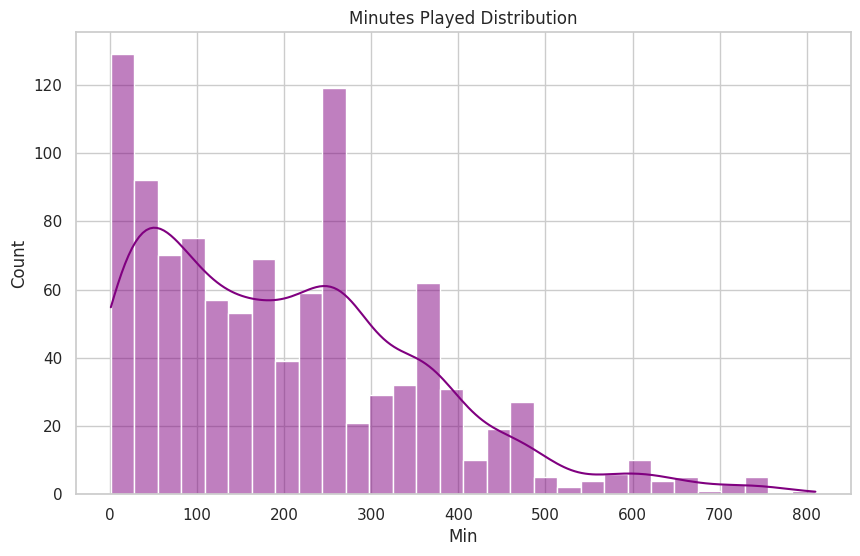

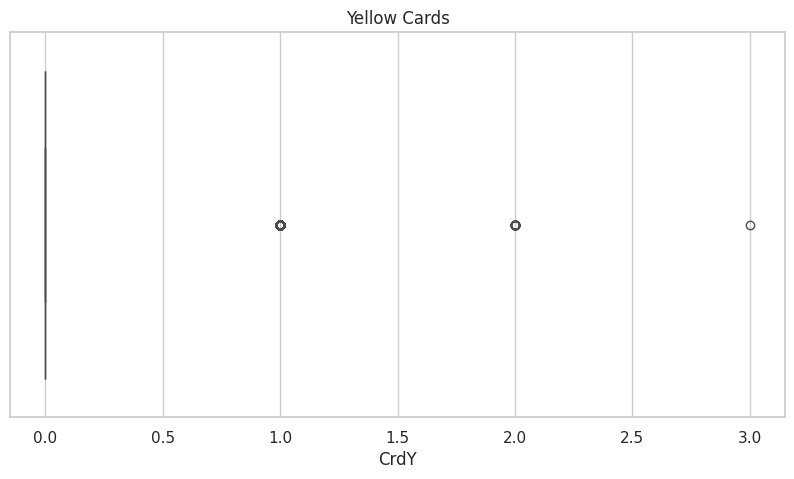

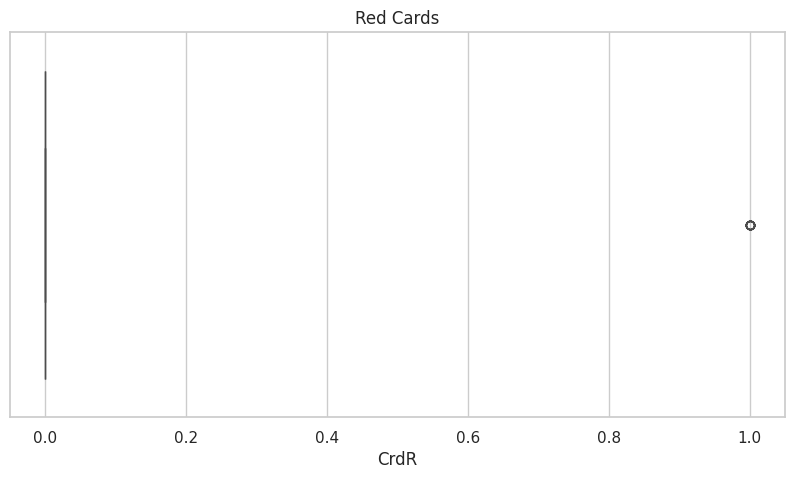

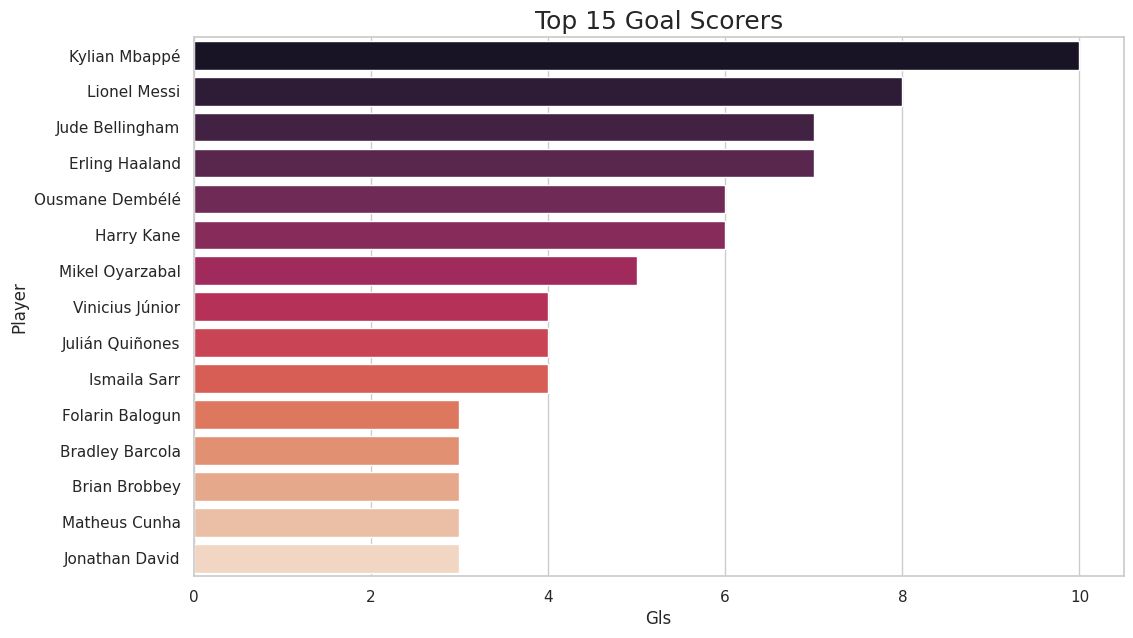

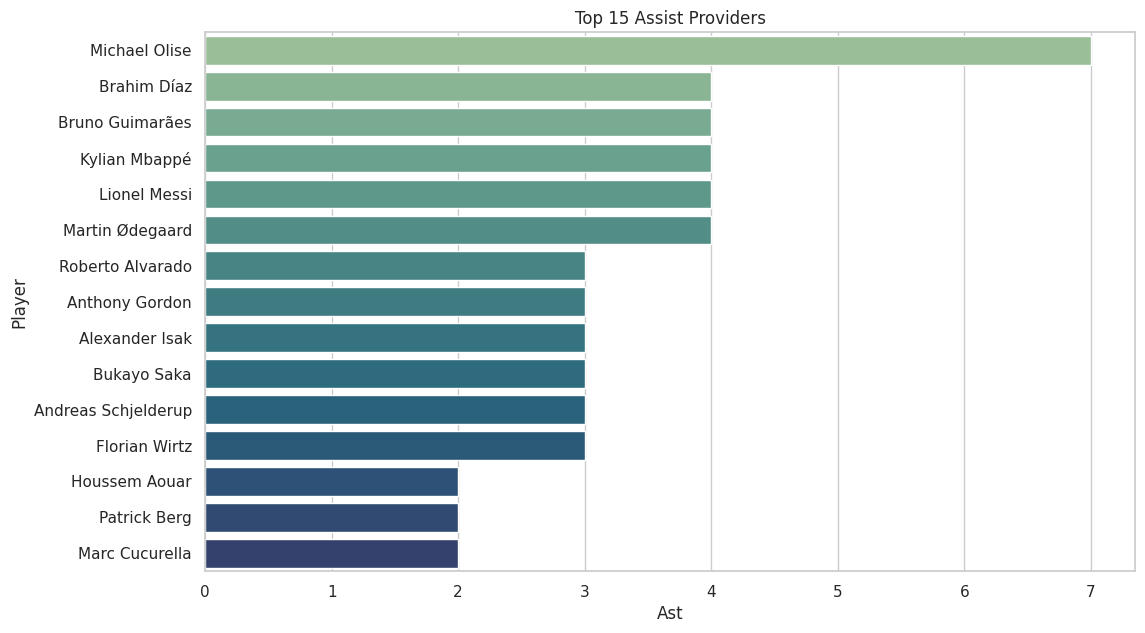

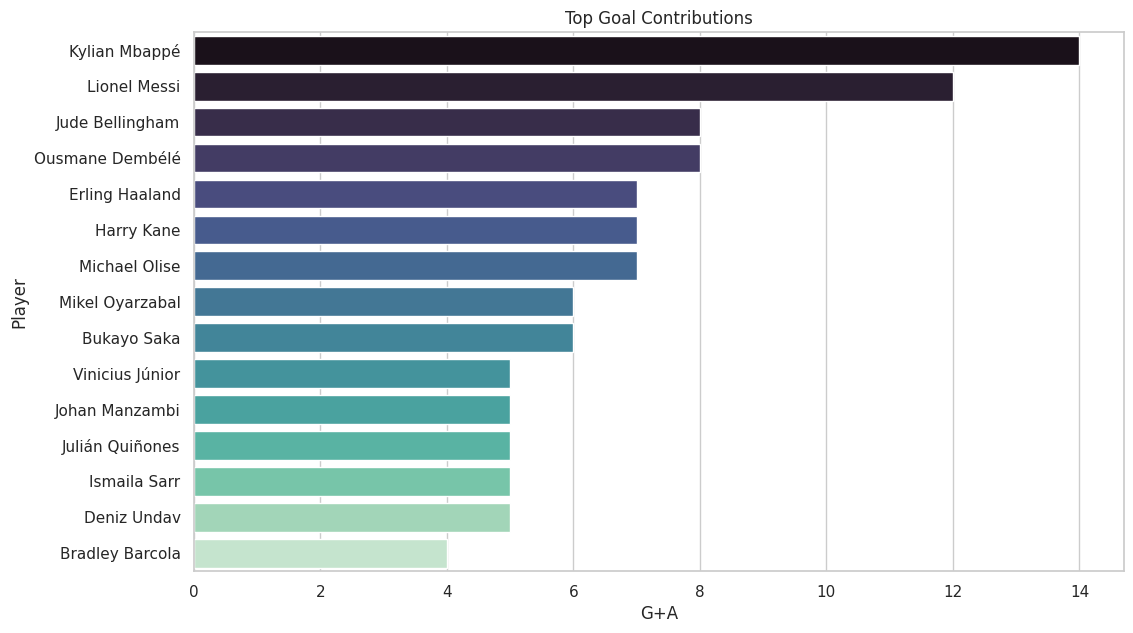

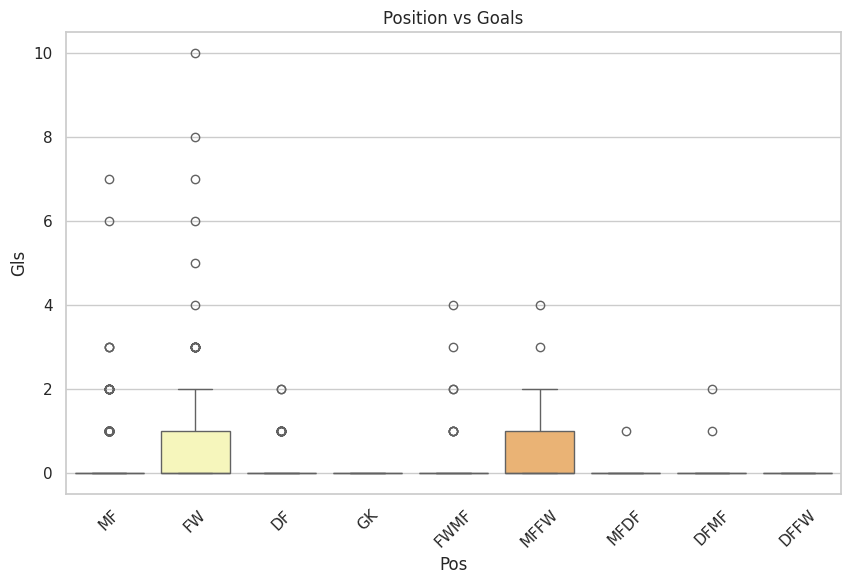

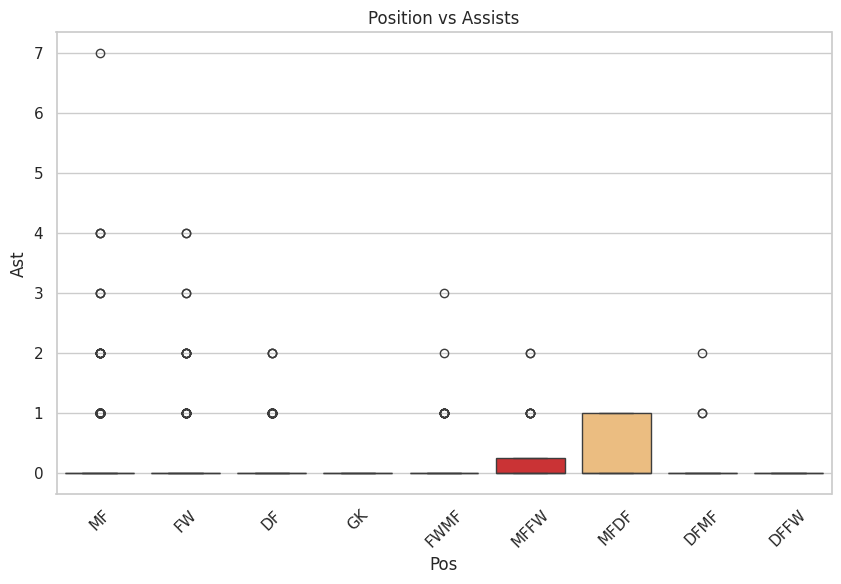

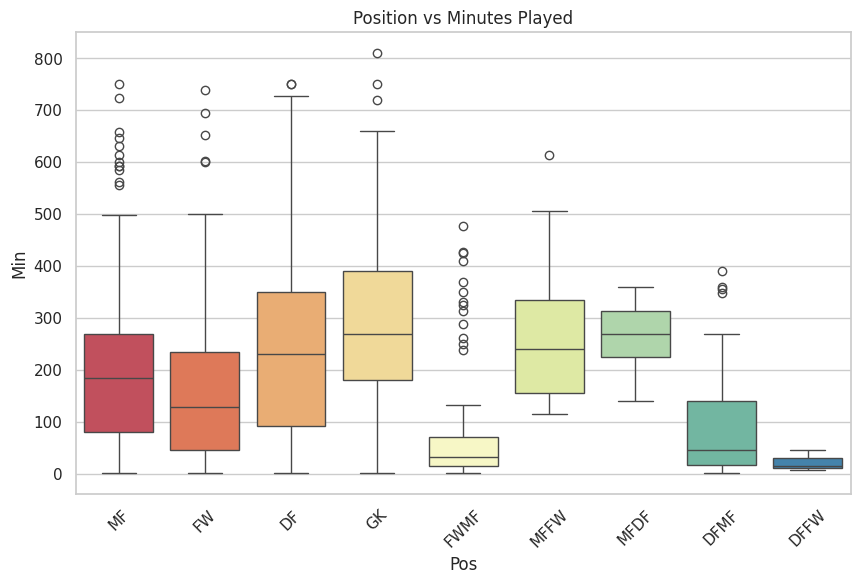

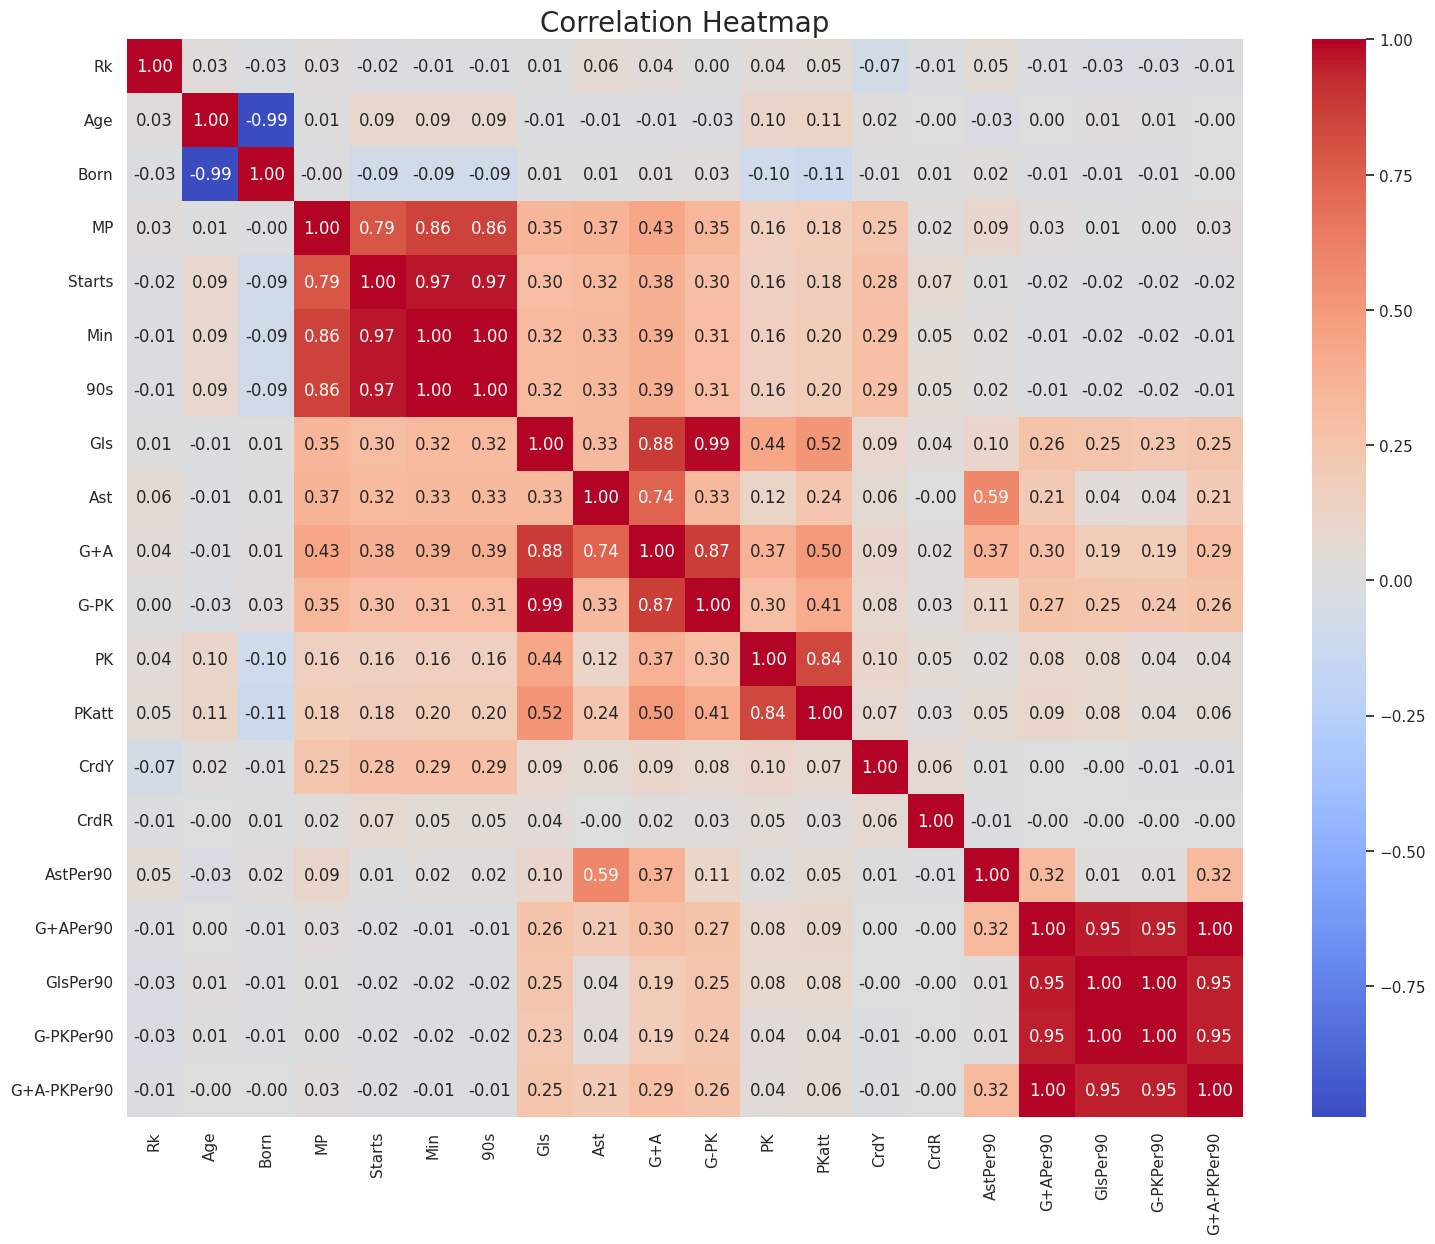

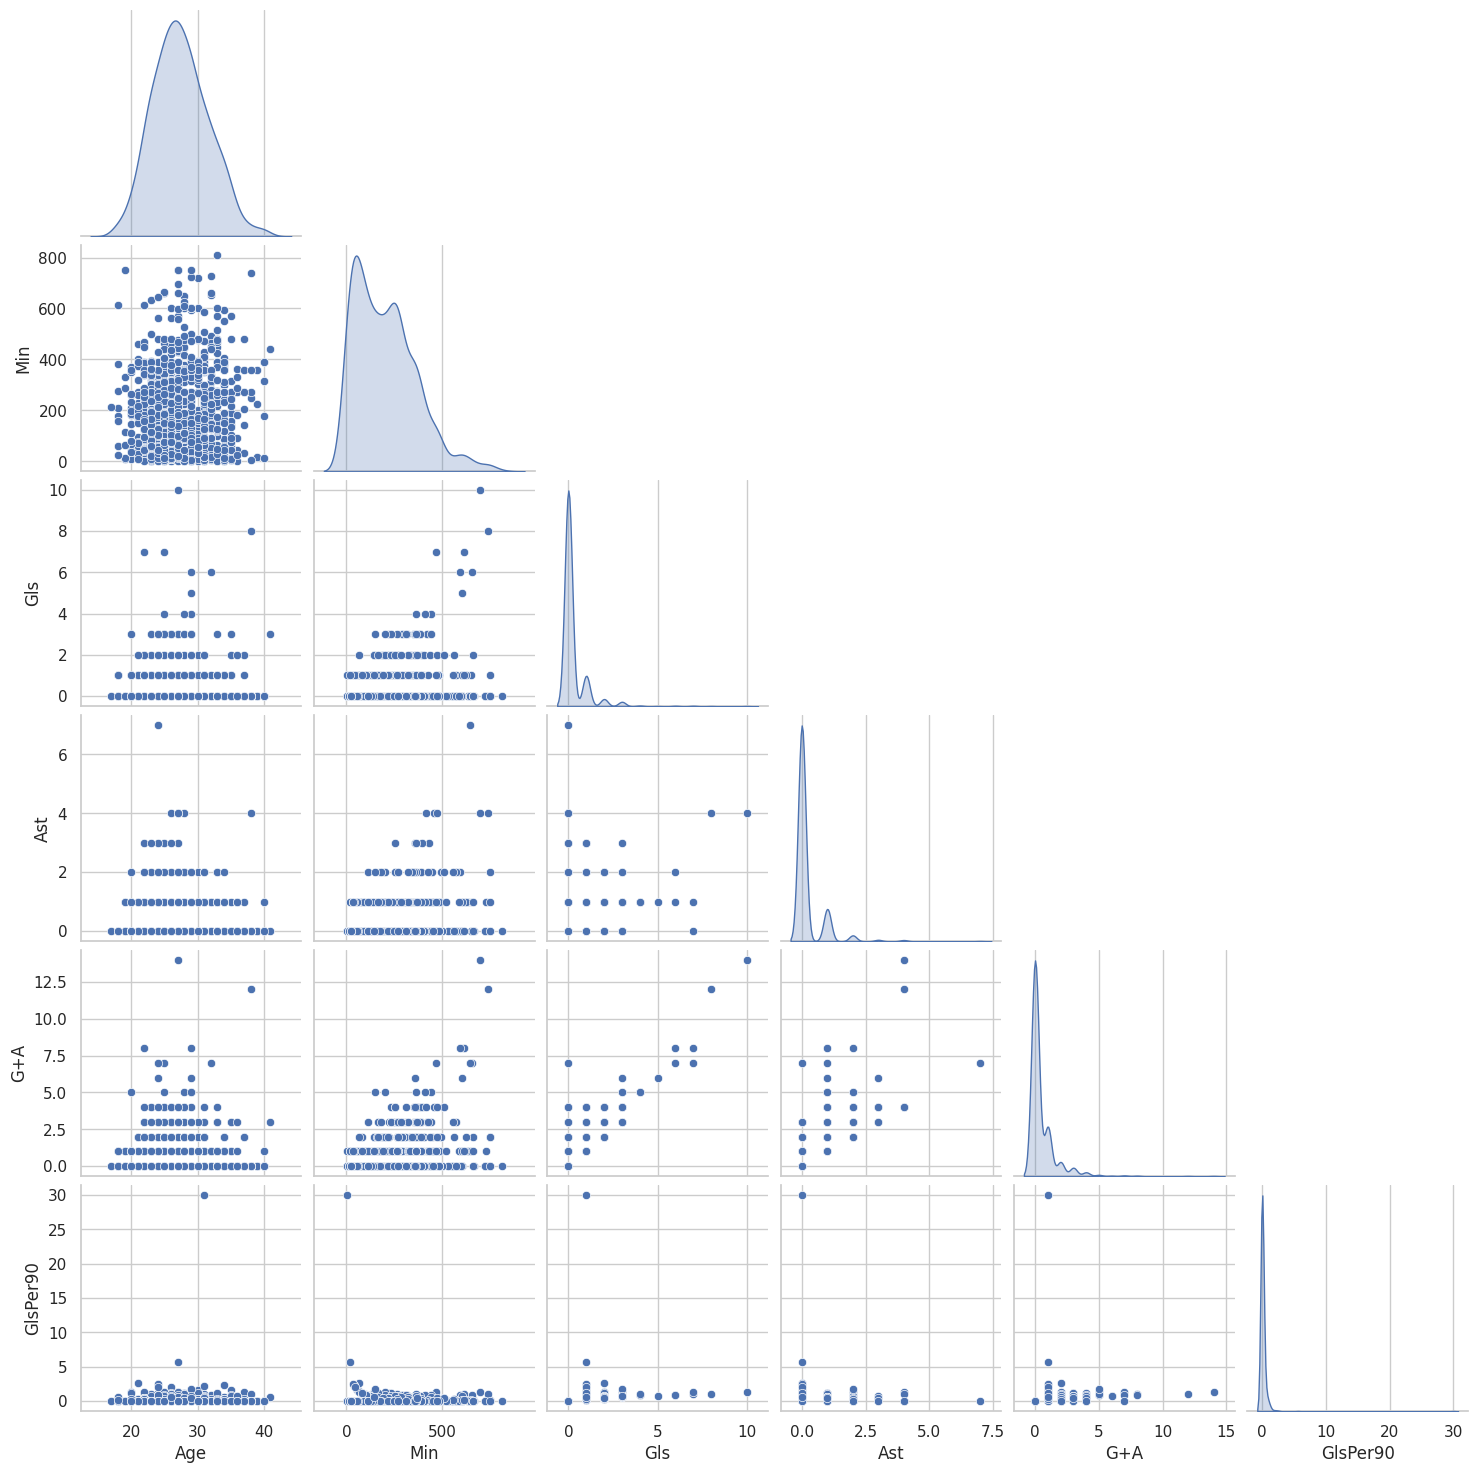

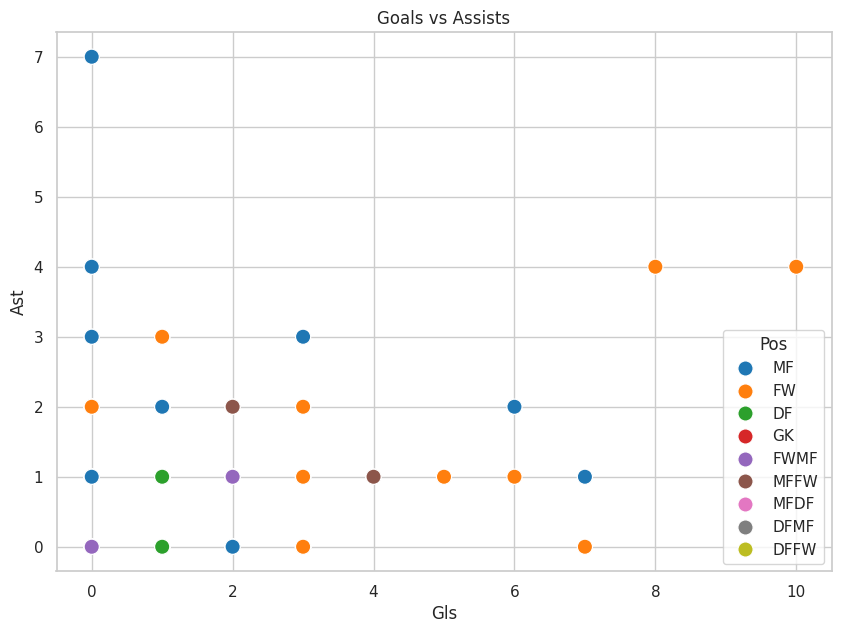

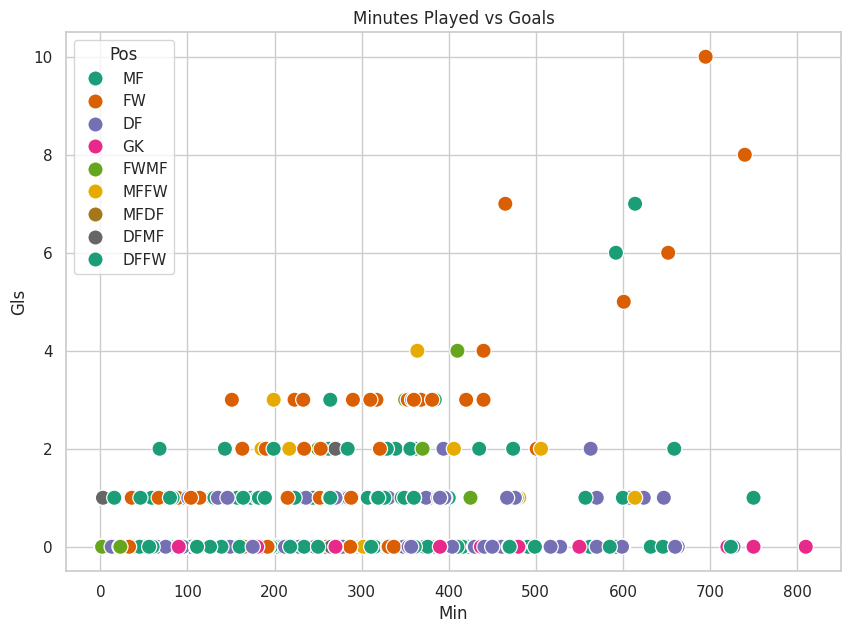

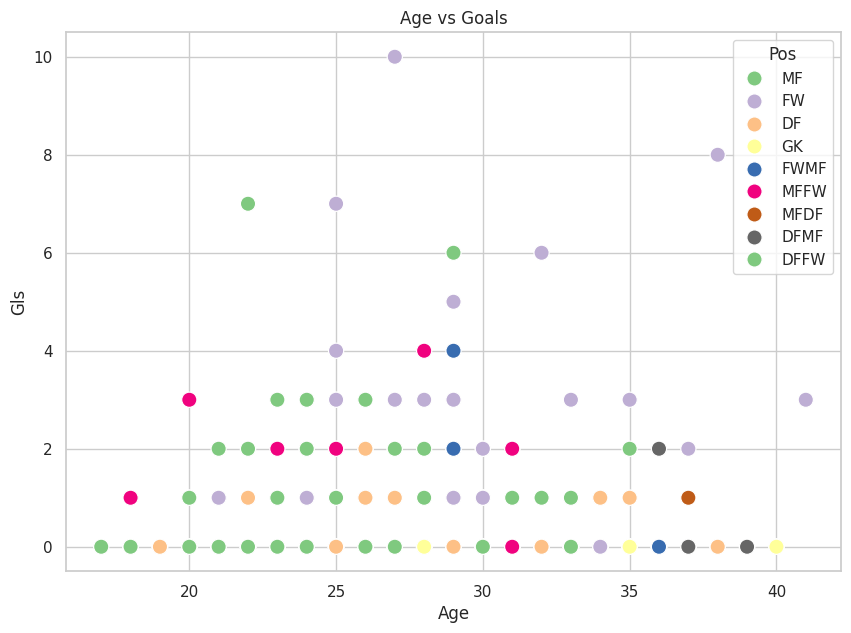

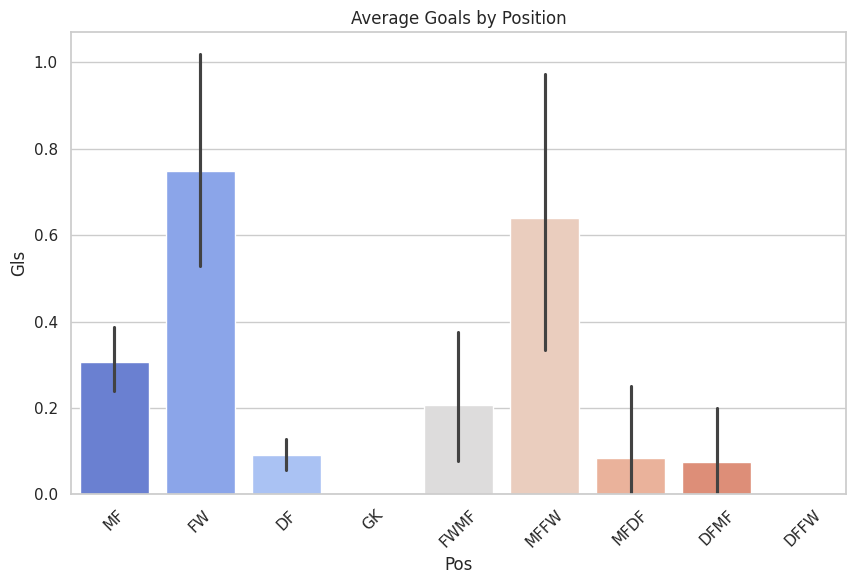

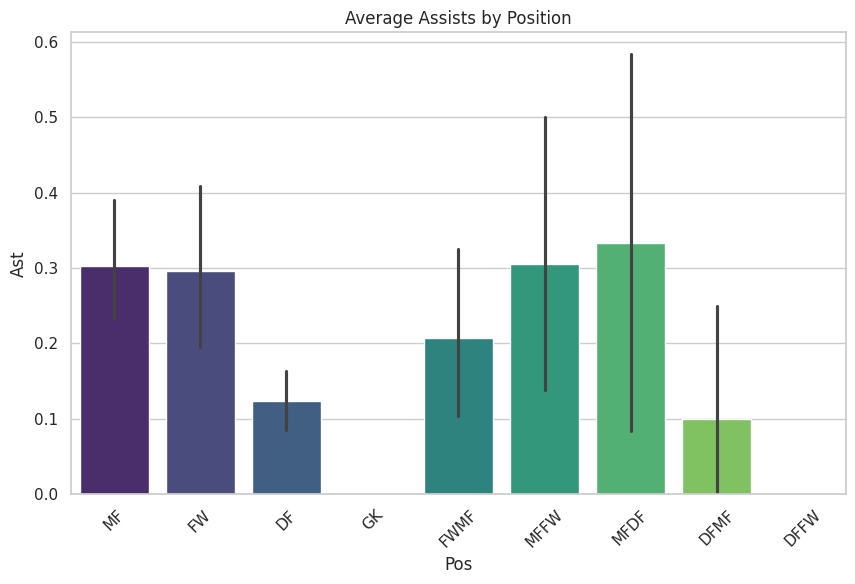

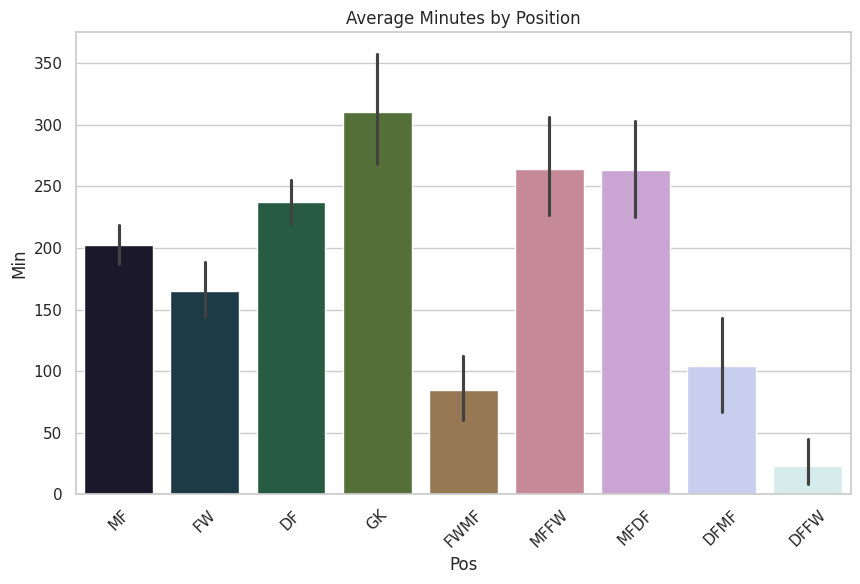

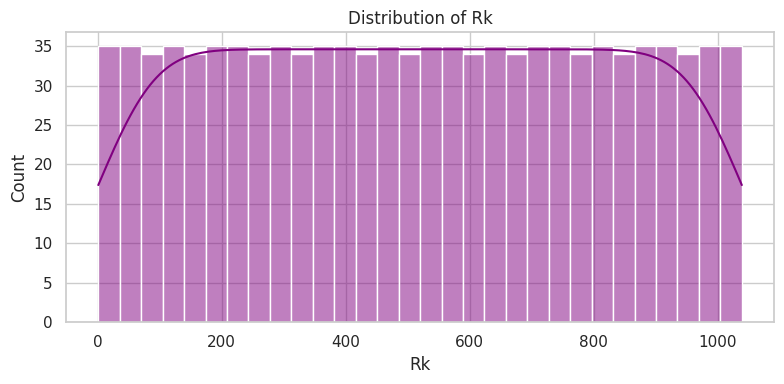

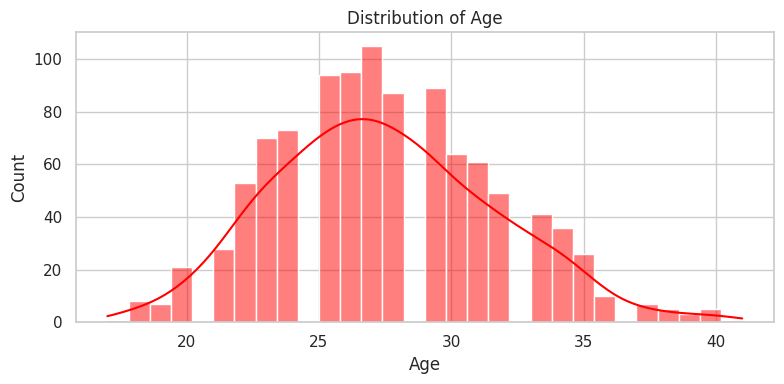

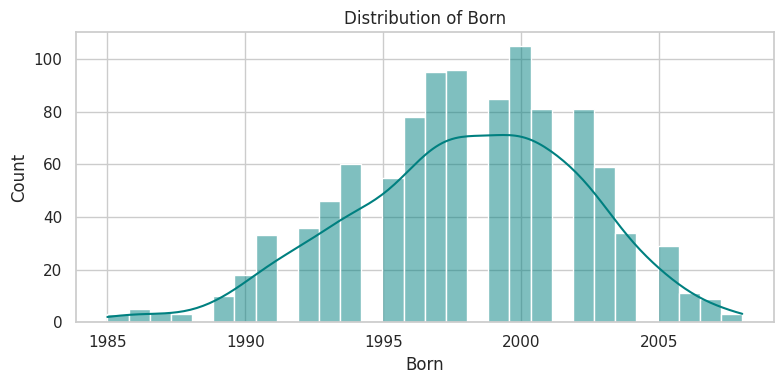

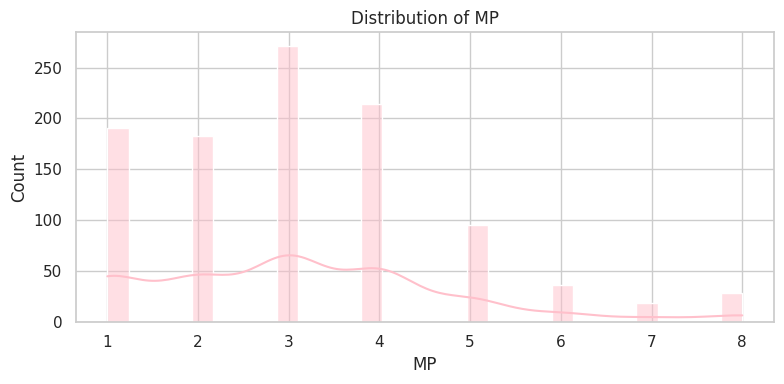

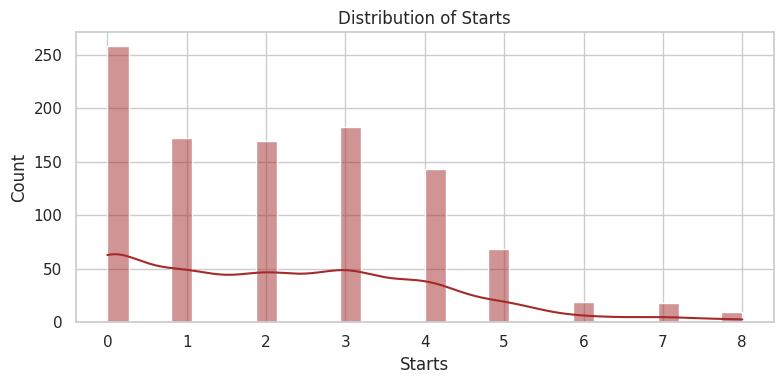

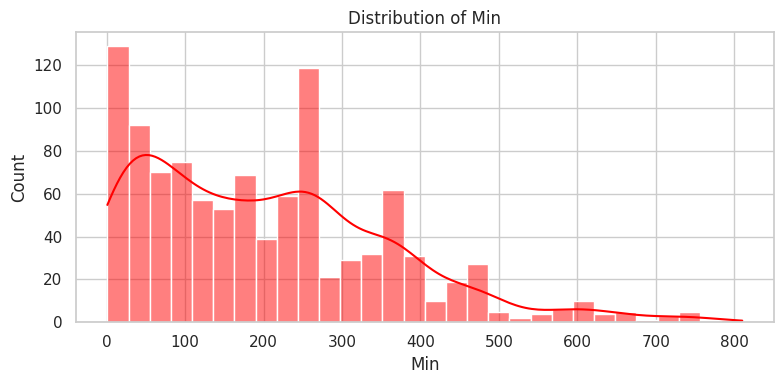

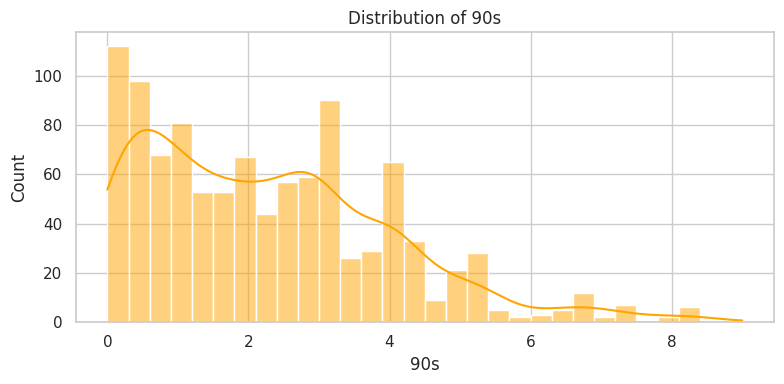

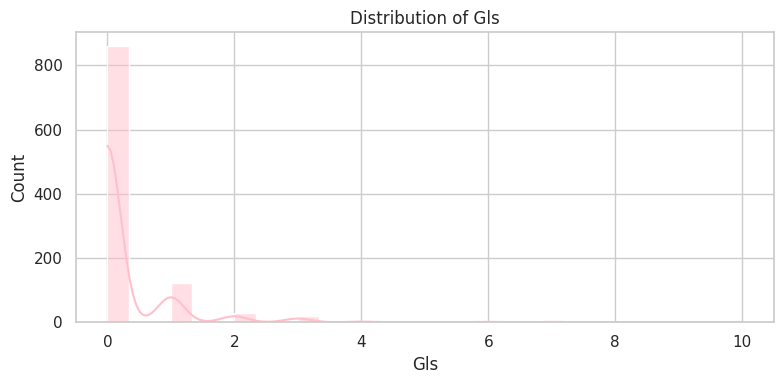

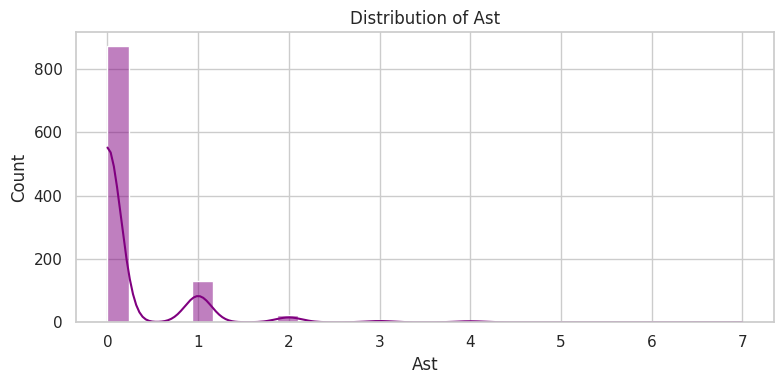

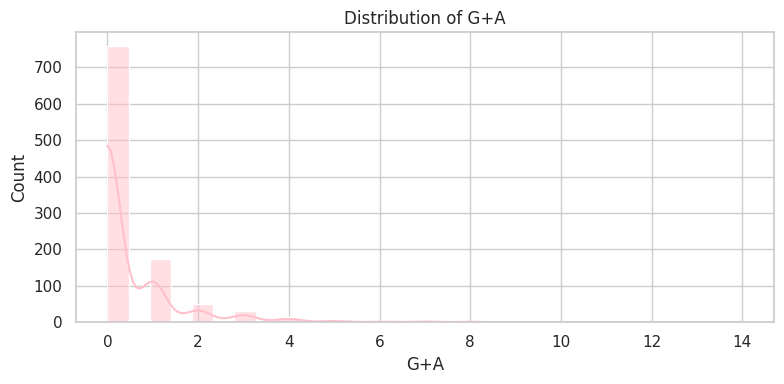

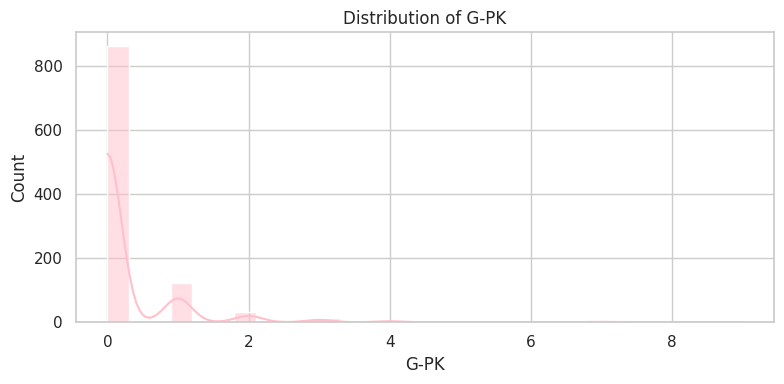

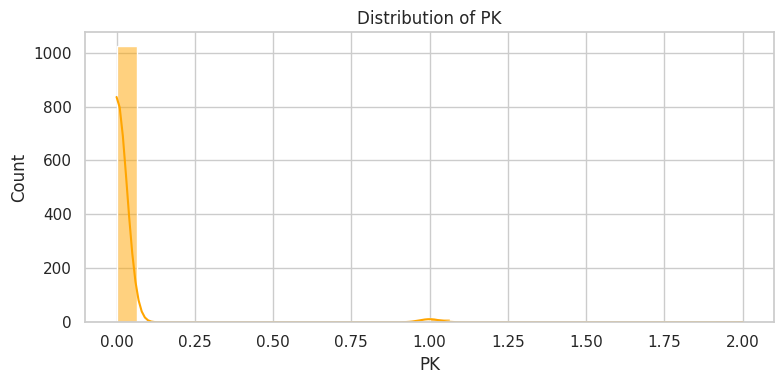

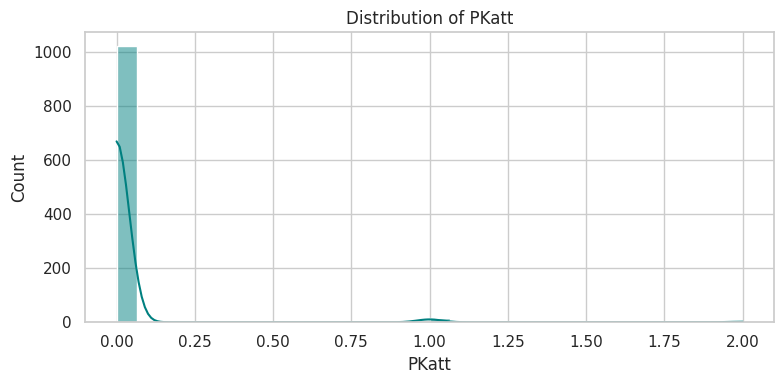

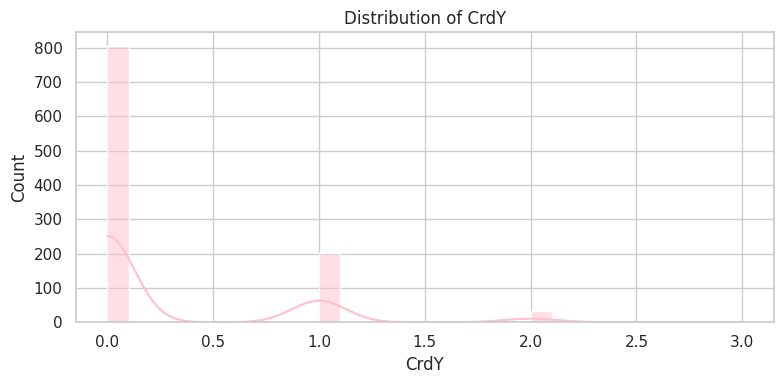

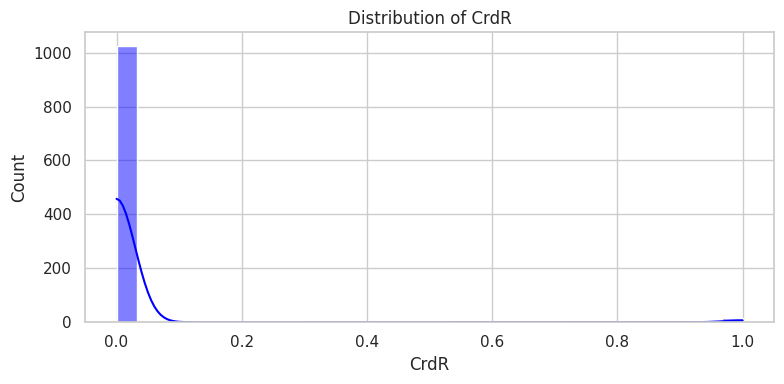

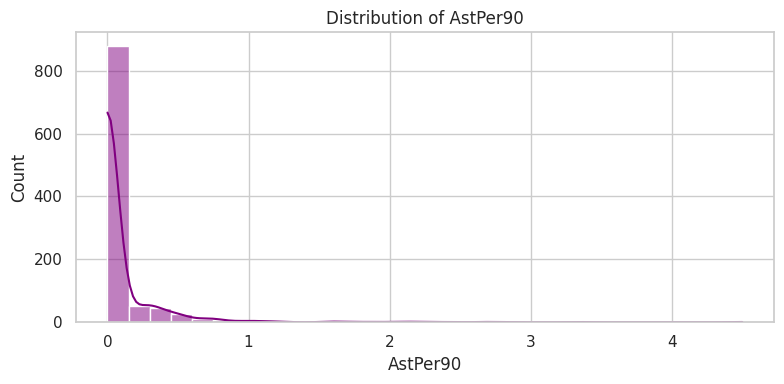

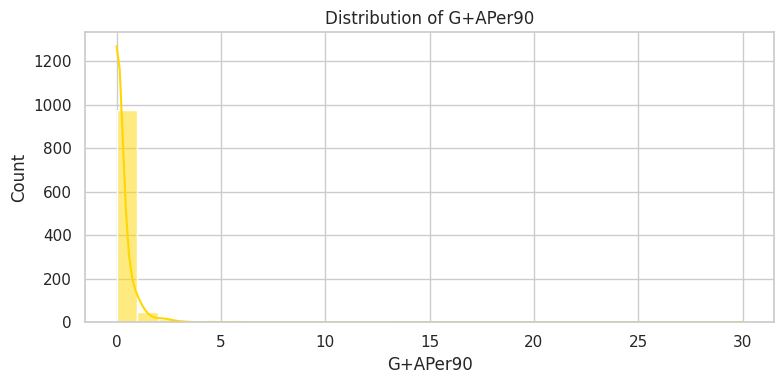

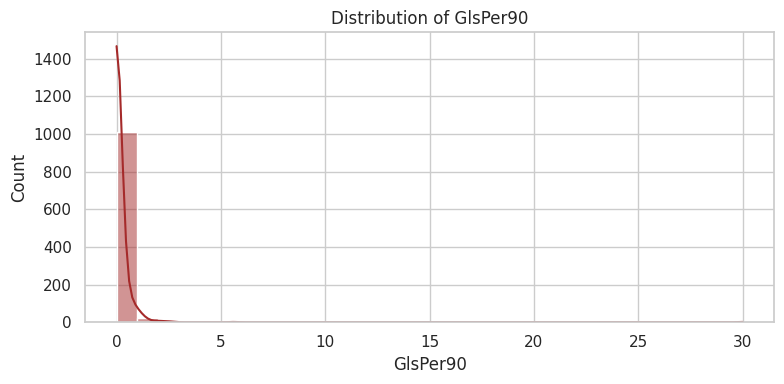

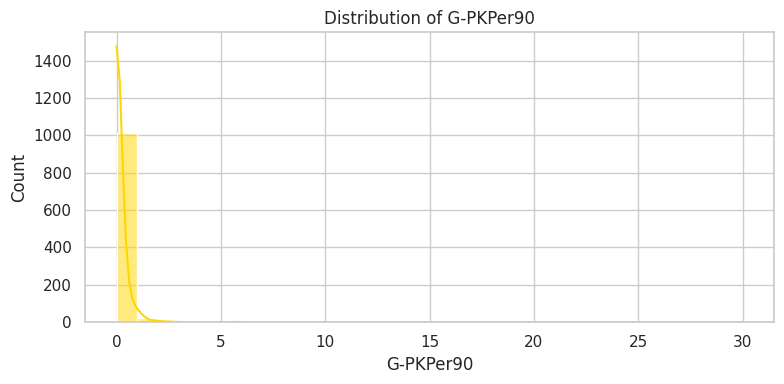

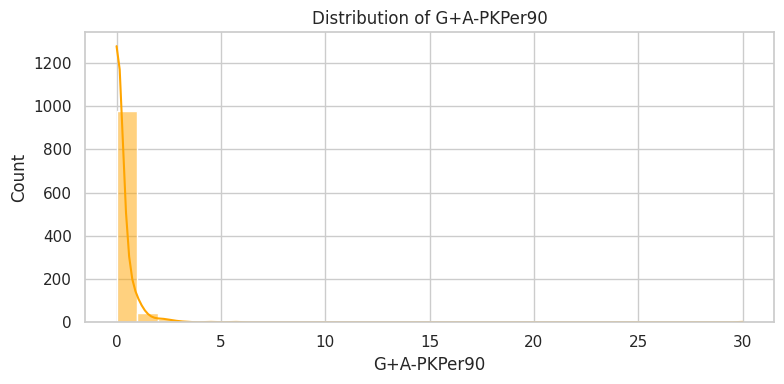


Visualization Completed Successfully!


In [12]:
# ==========================================
# FOOTBALL PLAYER DATASET - COMPLETE EDA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# -----------------------------
# Dataset Information
# -----------------------------
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")
print("="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n")
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

# Numerical & Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

# ==========================================
# 1. Missing Values Heatmap
# ==========================================

plt.figure(figsize=(15,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap",fontsize=18)
plt.show()

# ==========================================
# 2. Player Position Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x="Pos",
              palette="Set2",
              order=df["Pos"].value_counts().index)

plt.xticks(rotation=45)
plt.title("Player Position Distribution",fontsize=18)
plt.show()

# ==========================================
# 3. Squad Distribution
# ==========================================

plt.figure(figsize=(15,7))
sns.countplot(data=df,
              y="Squad",
              palette="tab20",
              order=df["Squad"].value_counts().index)

plt.title("Players in Each Squad",fontsize=18)
plt.show()

# ==========================================
# 4. Age Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(df["Age"],
             bins=20,
             kde=True,
             color="dodgerblue")

plt.title("Age Distribution",fontsize=18)
plt.show()

# ==========================================
# 5. Age Boxplot
# ==========================================

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Age"],color="orange")
plt.title("Age Boxplot")
plt.show()

# ==========================================
# 6. Goals Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(df["Gls"],
             bins=25,
             color="crimson",
             kde=True)

plt.title("Goal Distribution")
plt.show()

# ==========================================
# 7. Assists Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(df["Ast"],
             bins=25,
             color="green",
             kde=True)

plt.title("Assist Distribution")
plt.show()

# ==========================================
# 8. Minutes Played Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(df["Min"],
             bins=30,
             color="purple",
             kde=True)

plt.title("Minutes Played Distribution")
plt.show()

# ==========================================
# 9. Yellow Cards
# ==========================================

plt.figure(figsize=(10,5))
sns.boxplot(x=df["CrdY"],color="gold")
plt.title("Yellow Cards")
plt.show()

# ==========================================
# 10. Red Cards
# ==========================================

plt.figure(figsize=(10,5))
sns.boxplot(x=df["CrdR"],color="red")
plt.title("Red Cards")
plt.show()

# ==========================================
# 11. Top 15 Goal Scorers
# ==========================================

top_goal=df.nlargest(15,"Gls")

plt.figure(figsize=(12,7))
sns.barplot(data=top_goal,
            x="Gls",
            y="Player",
            palette="rocket")

plt.title("Top 15 Goal Scorers",fontsize=18)
plt.show()

# ==========================================
# 12. Top 15 Assist Providers
# ==========================================

top_ast=df.nlargest(15,"Ast")

plt.figure(figsize=(12,7))
sns.barplot(data=top_ast,
            x="Ast",
            y="Player",
            palette="crest")

plt.title("Top 15 Assist Providers")
plt.show()

# ==========================================
# 13. Top Players by G+A
# ==========================================

top_ga=df.nlargest(15,"G+A")

plt.figure(figsize=(12,7))
sns.barplot(data=top_ga,
            x="G+A",
            y="Player",
            palette="mako")

plt.title("Top Goal Contributions")
plt.show()

# ==========================================
# 14. Position vs Goals
# ==========================================

plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x="Pos",
            y="Gls",
            palette="Set3")

plt.xticks(rotation=45)
plt.title("Position vs Goals")
plt.show()

# ==========================================
# 15. Position vs Assists
# ==========================================

plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x="Pos",
            y="Ast",
            palette="Paired")

plt.xticks(rotation=45)
plt.title("Position vs Assists")
plt.show()

# ==========================================
# 16. Position vs Minutes Played
# ==========================================

plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x="Pos",
            y="Min",
            palette="Spectral")

plt.xticks(rotation=45)
plt.title("Position vs Minutes Played")
plt.show()

# ==========================================
# 17. Correlation Heatmap
# ==========================================

plt.figure(figsize=(18,14))

corr=df[num_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap",fontsize=20)
plt.show()

# ==========================================
# 18. Pairplot (Important Features)
# ==========================================

important=["Age","Min","Gls","Ast","G+A","GlsPer90"]

sns.pairplot(df[important],
             corner=True,
             diag_kind="kde")

plt.show()

# ==========================================
# 19. Goals vs Assists
# ==========================================

plt.figure(figsize=(10,7))

sns.scatterplot(data=df,
                x="Gls",
                y="Ast",
                hue="Pos",
                palette="tab10",
                s=120)

plt.title("Goals vs Assists")
plt.show()

# ==========================================
# 20. Minutes vs Goals
# ==========================================

plt.figure(figsize=(10,7))

sns.scatterplot(data=df,
                x="Min",
                y="Gls",
                hue="Pos",
                palette="Dark2",
                s=120)

plt.title("Minutes Played vs Goals")
plt.show()

# ==========================================
# 21. Age vs Goals
# ==========================================

plt.figure(figsize=(10,7))

sns.scatterplot(data=df,
                x="Age",
                y="Gls",
                hue="Pos",
                palette="Accent",
                s=120)

plt.title("Age vs Goals")
plt.show()

# ==========================================
# 22. Average Goals by Position
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(data=df,
            x="Pos",
            y="Gls",
            estimator=np.mean,
            palette="coolwarm")

plt.xticks(rotation=45)
plt.title("Average Goals by Position")
plt.show()

# ==========================================
# 23. Average Assists by Position
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(data=df,
            x="Pos",
            y="Ast",
            estimator=np.mean,
            palette="viridis")

plt.xticks(rotation=45)
plt.title("Average Assists by Position")
plt.show()

# ==========================================
# 24. Average Minutes by Position
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(data=df,
            x="Pos",
            y="Min",
            estimator=np.mean,
            palette="cubehelix")

plt.xticks(rotation=45)
plt.title("Average Minutes by Position")
plt.show()

# ==========================================
# 25. Distribution of Every Numerical Feature
# ==========================================

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col],
                 bins=30,
                 kde=True,
                 color=np.random.choice([
                     "red","blue","green","purple",
                     "orange","brown","pink",
                     "teal","gold","navy"
                 ]))
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

print("\nVisualization Completed Successfully!")

## Features Engineering

Classes :
['DF' 'DFFW' 'DFMF' 'FW' 'FWMF' 'GK' 'MF' 'MFDF' 'MFFW']

Training Shape : (831, 21)
Testing Shape : (208, 21)


Logistic Regression
Accuracy  : 0.3221
Precision : 0.2959
Recall    : 0.3221
F1 Score  : 0.3018

Classification Report

              precision    recall  f1-score   support

          DF       0.41      0.48      0.44        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.00      0.00      0.00         8
          FW       0.16      0.12      0.14        32
        FWMF       0.00      0.00      0.00        16
          GK       0.60      0.25      0.35        12
          MF       0.35      0.45      0.39        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.32       208
   macro avg       0.17      0.14      0.15       208
weighted avg       0.30      0.32      0.30       208



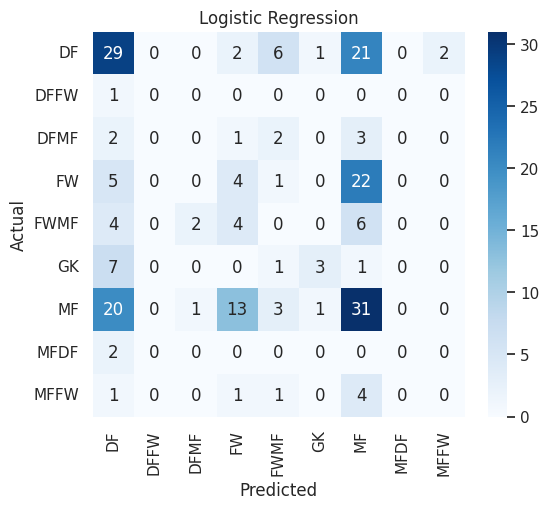



Decision Tree
Accuracy  : 0.3750
Precision : 0.3602
Recall    : 0.3750
F1 Score  : 0.3656

Classification Report

              precision    recall  f1-score   support

          DF       0.44      0.44      0.44        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.40      0.25      0.31         8
          FW       0.22      0.19      0.20        32
        FWMF       0.39      0.44      0.41        16
          GK       0.27      0.25      0.26        12
          MF       0.41      0.48      0.44        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.38       208
   macro avg       0.24      0.23      0.23       208
weighted avg       0.36      0.38      0.37       208



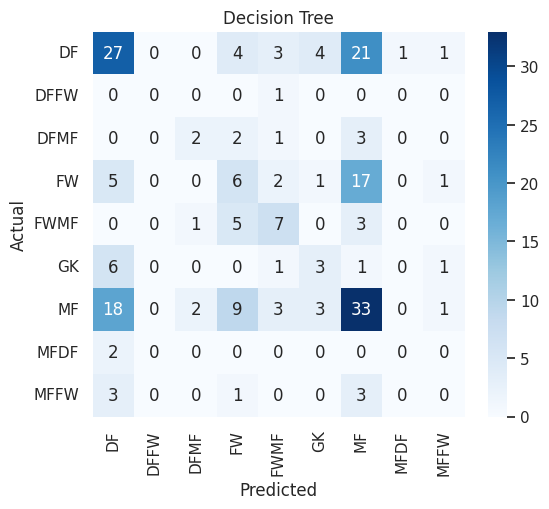



Random Forest
Accuracy  : 0.4567
Precision : 0.4027
Recall    : 0.4567
F1 Score  : 0.4196

Classification Report

              precision    recall  f1-score   support

          DF       0.49      0.52      0.51        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.00      0.00      0.00         8
          FW       0.41      0.28      0.33        32
        FWMF       0.69      0.56      0.62        16
          GK       0.00      0.00      0.00        12
          MF       0.43      0.65      0.52        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.46       208
   macro avg       0.22      0.22      0.22       208
weighted avg       0.40      0.46      0.42       208



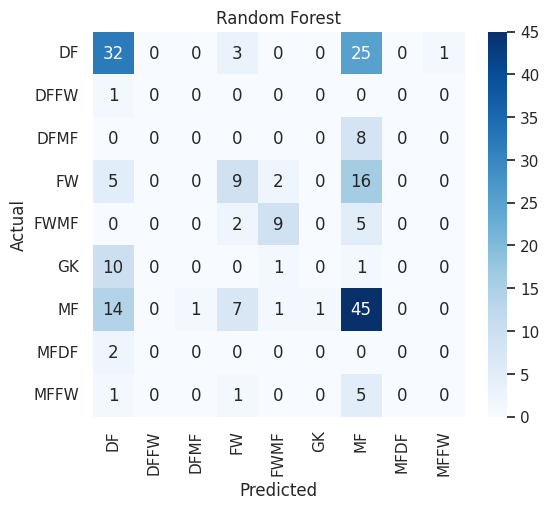



Extra Trees
Accuracy  : 0.3990
Precision : 0.3474
Recall    : 0.3990
F1 Score  : 0.3690

Classification Report

              precision    recall  f1-score   support

          DF       0.45      0.51      0.48        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.00      0.00      0.00         8
          FW       0.33      0.28      0.31        32
        FWMF       0.47      0.44      0.45        16
          GK       0.00      0.00      0.00        12
          MF       0.39      0.52      0.44        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.40       208
   macro avg       0.18      0.19      0.19       208
weighted avg       0.35      0.40      0.37       208



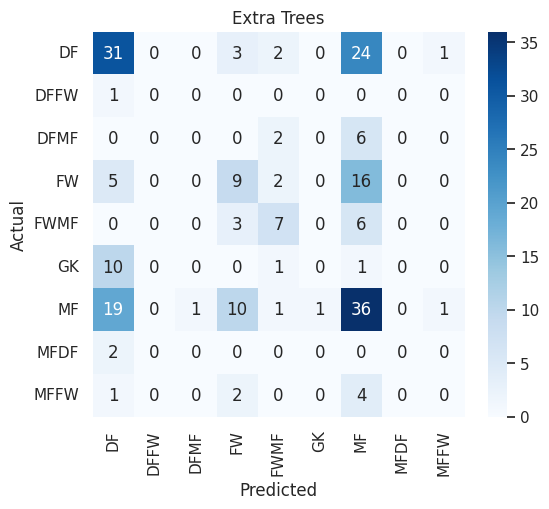



Gradient Boosting
Accuracy  : 0.3798
Precision : 0.3461
Recall    : 0.3798
F1 Score  : 0.3466

Classification Report

              precision    recall  f1-score   support

          DF       0.49      0.49      0.49        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.00      0.00      0.00         8
          FW       0.33      0.16      0.21        32
        FWMF       0.44      0.25      0.32        16
          GK       0.00      0.00      0.00        12
          MF       0.35      0.58      0.44        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.38       208
   macro avg       0.18      0.16      0.16       208
weighted avg       0.35      0.38      0.35       208



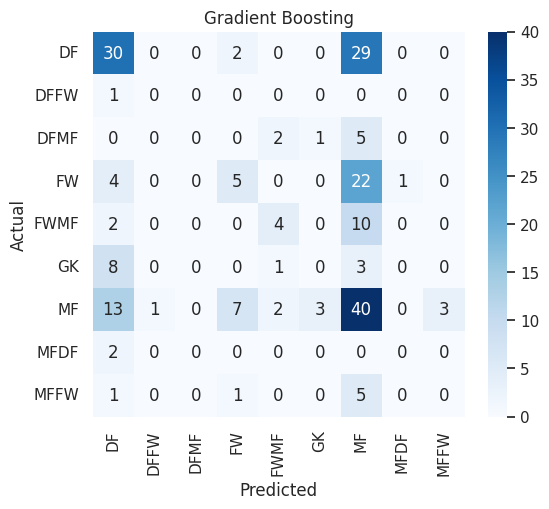



AdaBoost
Accuracy  : 0.3365
Precision : 0.2899
Recall    : 0.3365
F1 Score  : 0.2878

Classification Report

              precision    recall  f1-score   support

          DF       0.32      0.67      0.43        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.00      0.00      0.00         8
          FW       0.32      0.19      0.24        32
        FWMF       0.20      0.06      0.10        16
          GK       0.00      0.00      0.00        12
          MF       0.40      0.32      0.35        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.34       208
   macro avg       0.14      0.14      0.12       208
weighted avg       0.29      0.34      0.29       208



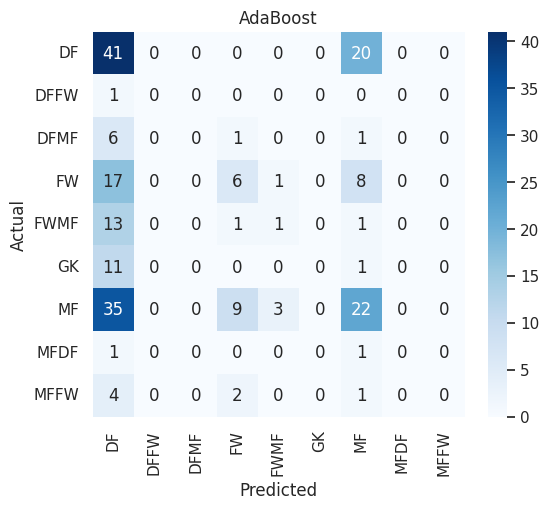



KNN
Accuracy  : 0.3798
Precision : 0.3619
Recall    : 0.3798
F1 Score  : 0.3609

Classification Report

              precision    recall  f1-score   support

          DF       0.43      0.64      0.52        61
        DFFW       0.00      0.00      0.00         1
        DFMF       0.33      0.25      0.29         8
          FW       0.23      0.28      0.25        32
        FWMF       0.58      0.44      0.50        16
          GK       0.29      0.17      0.21        12
          MF       0.38      0.29      0.33        69
        MFDF       0.00      0.00      0.00         2
        MFFW       0.00      0.00      0.00         7

    accuracy                           0.38       208
   macro avg       0.25      0.23      0.23       208
weighted avg       0.36      0.38      0.36       208



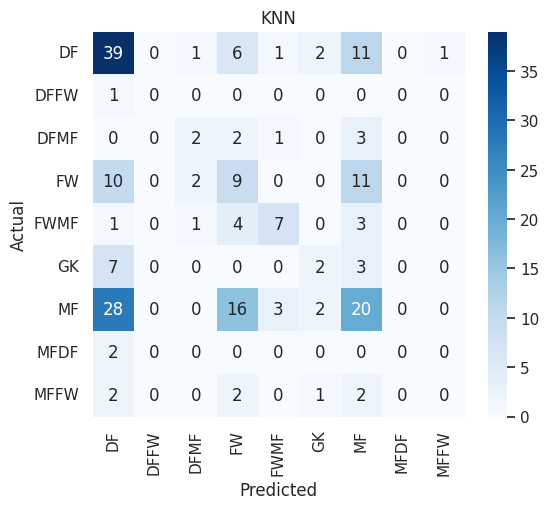



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.456731   0.402741  0.456731  0.419574
3          Extra Trees  0.399038   0.347350  0.399038  0.368978
4    Gradient Boosting  0.379808   0.346098  0.379808  0.346598
6                  KNN  0.379808   0.361944  0.379808  0.360854
1        Decision Tree  0.375000   0.360179  0.375000  0.365619
5             AdaBoost  0.336538   0.289870  0.336538  0.287805
0  Logistic Regression  0.322115   0.295876  0.322115  0.301817


BEST MODEL
Random Forest
Accuracy : 0.4567


In [13]:
# =====================================================
# FOOTBALL PLAYER POSITION PREDICTION - PART 1
# Data Preprocessing + ML Models
# =====================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ======================================
# Visualization
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# Machine Learning
# ======================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# ======================================
# Models
# ======================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ======================================
# Metrics
# ======================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =====================================================
# COPY DATA
# =====================================================

data = df.copy()

# =====================================================
# REMOVE DATA LEAKAGE COLUMNS
# =====================================================

drop_columns = [
    "Rk",
    "Player",
    "PlayerID"
]

for col in drop_columns:
    if col in data.columns:
        data.drop(columns=col, inplace=True)

# =====================================================
# REMOVE DUPLICATES
# =====================================================

data.drop_duplicates(inplace=True)

# =====================================================
# TARGET COLUMN
# =====================================================

target = "Pos"

X = data.drop(columns=[target])
y = data[target]

# =====================================================
# LABEL ENCODE TARGET
# =====================================================

label = LabelEncoder()

y = label.fit_transform(y)

print("Classes :")
print(label.classes_)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# =====================================================
# NUMERIC & CATEGORICAL
# =====================================================

numeric_features = X_train.select_dtypes(include=np.number).columns

categorical_features = X_train.select_dtypes(exclude=np.number).columns

# =====================================================
# PREPROCESSING
# =====================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# =====================================================
# MODELS
# =====================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5)
}

# =====================================================
# STORE RESULTS
# =====================================================

results = []

best_model = None
best_accuracy = 0

# =====================================================
# TRAIN MODELS
# =====================================================

for name, model in models.items():

    print("\n")
    print("=" * 80)
    print(name)
    print("=" * 80)

    # -----------------------------------

    if name == "Gaussian NB":

        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        model.fit(
            X_train_processed,
            y_train
        )

        prediction = model.predict(
            X_test_processed
        )

    else:

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(
            X_train,
            y_train
        )

        prediction = pipe.predict(
            X_test
        )

    # -----------------------------------

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted"
    )

    # -----------------------------------

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # -----------------------------------

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            prediction,
            target_names=label.classes_
        )
    )

    # -----------------------------------

    cm = confusion_matrix(
        y_test,
        prediction
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label.classes_,
        yticklabels=label.classes_
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # -----------------------------------

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # -----------------------------------

    if accuracy > best_accuracy:

        best_accuracy = accuracy
        best_model = name

# =====================================================
# RESULTS
# =====================================================

results = pd.DataFrame(results)

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

print(results)

print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(best_model)
print("Accuracy :", round(best_accuracy,4))

CROSS VALIDATION
Logistic Regression
Scores : [0.34730539 0.36746988 0.40963855 0.34337349 0.39759036]
Average : 0.37307553567563667

Decision Tree
Scores : [0.30538922 0.36746988 0.28313253 0.37349398 0.3373494 ]
Average : 0.33336700093788324

Random Forest
Scores : [0.35928144 0.39156627 0.38554217 0.43975904 0.37951807]
Average : 0.3911333958588846

Extra Trees
Scores : [0.34730539 0.36746988 0.36144578 0.39156627 0.37349398]
Average : 0.36825625856720295

Gradient Boosting
Scores : [0.2994012  0.36144578 0.34337349 0.34337349 0.40361446]
Average : 0.35024168530409067

AdaBoost
Scores : [0.33532934 0.37349398 0.36746988 0.3313253  0.34337349]
Average : 0.350198398383955

KNN
Scores : [0.35329341 0.40361446 0.39759036 0.40963855 0.3373494 ]
Average : 0.380297236851598

HYPERPARAMETER TUNING
Best Accuracy : 0.41035278839910544

Best Parameters
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 20}


FINAL TEST RESULT
Accuracy

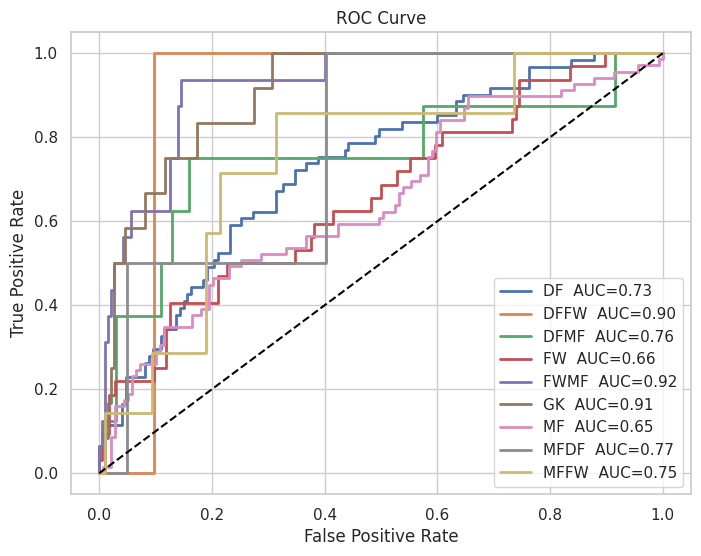

FEATURE IMPORTANCE
                   Feature  Importance
4                 num__Min    0.068392
5                 num__90s    0.060875
0                 num__Age    0.046953
1                num__Born    0.046312
3              num__Starts    0.043991
2                  num__MP    0.031344
15           num__G+APer90    0.030455
18        num__G+A-PKPer90    0.028285
17          num__G-PKPer90    0.023074
16           num__GlsPer90    0.022687
12               num__CrdY    0.017419
8                 num__G+A    0.017399
14           num__AstPer90    0.016601
6                 num__Gls    0.014328
9                num__G-PK    0.010644
7                 num__Ast    0.008769
11              num__PKatt    0.006596
42     cat__Squad_ht Haiti    0.005753
29  cat__Squad_co Colombia    0.005750
51    cat__Squad_no Norway    0.005510


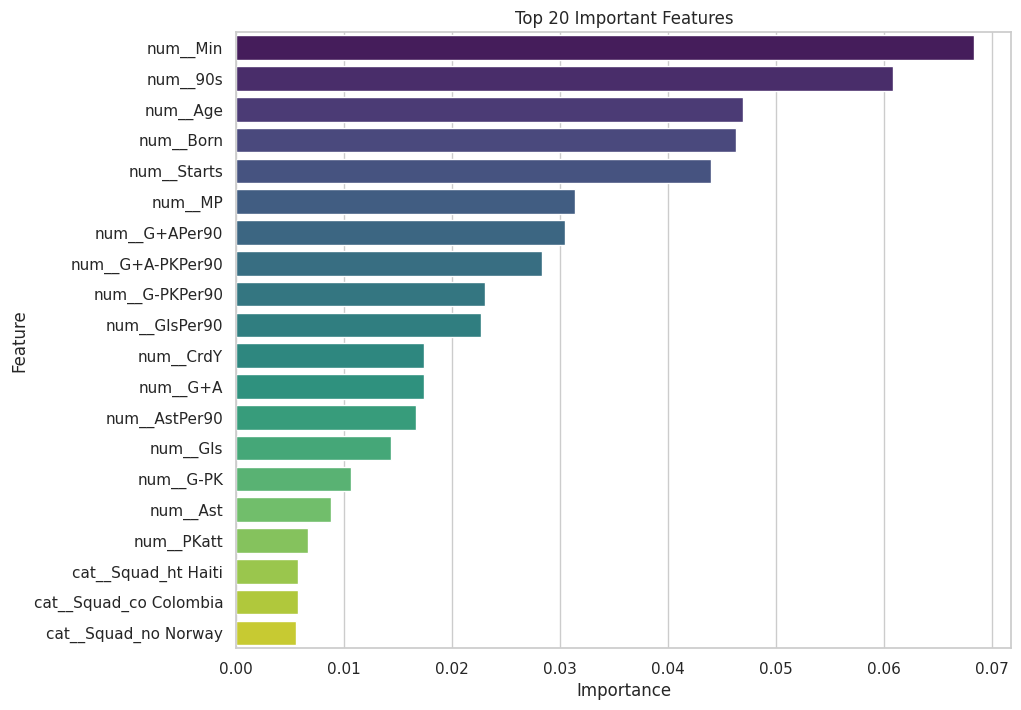


Model Saved Successfully!


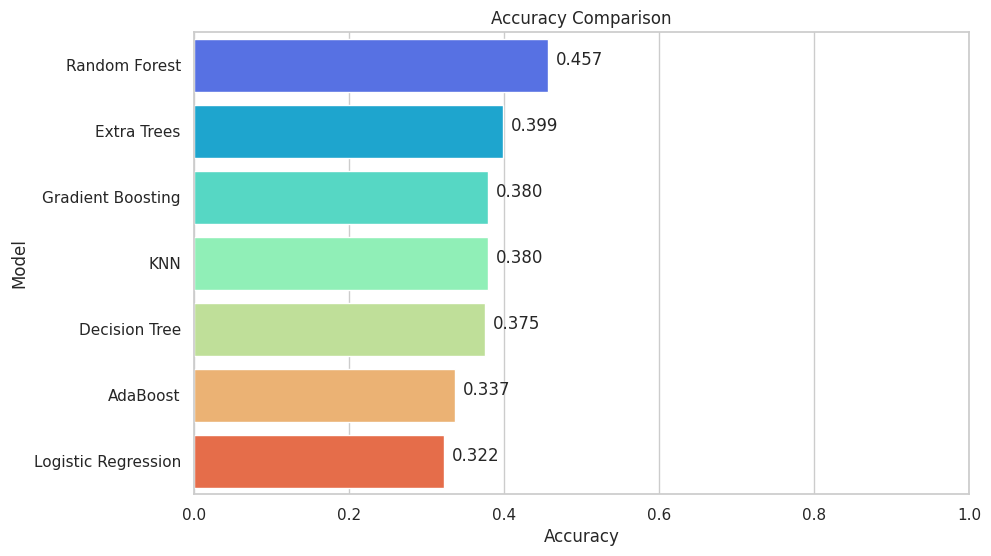

BEST MODEL
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A',
       'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'AstPer90', 'G+APer90',
       'GlsPer90', 'G-PKPer90', 'G+A-PKPer90'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                             

In [14]:
# =====================================================
# PART 2
# ROC CURVE + CROSS VALIDATION +
# HYPERPARAMETER TUNING +
# FEATURE IMPORTANCE +
# SAVE MODEL
# =====================================================

from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import joblib

# =====================================================
# CROSS VALIDATION
# =====================================================

print("="*80)
print("CROSS VALIDATION")
print("="*80)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    print(f"{name}")
    print("Scores :", scores)
    print("Average :", scores.mean())
    print()

# =====================================================
# RANDOM FOREST TUNING
# =====================================================

print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {

    "model__n_estimators":[100,200,300,500],

    "model__max_depth":[
        None,10,20,30
    ],

    "model__min_samples_split":[
        2,5,10
    ],

    "model__min_samples_leaf":[
        1,2,4
    ]
}

search = RandomizedSearchCV(

    estimator=pipe,

    param_distributions=param_grid,

    n_iter=10,

    cv=5,

    random_state=42,

    scoring="accuracy",

    n_jobs=-1

)

search.fit(
    X_train,
    y_train
)

print("Best Accuracy :", search.best_score_)
print()
print("Best Parameters")
print(search.best_params_)

best_model = search.best_estimator_

# =====================================================
# TEST ACCURACY
# =====================================================

prediction = best_model.predict(
    X_test
)

print("\n")
print("="*80)
print("FINAL TEST RESULT")
print("="*80)

print("Accuracy :",
      accuracy_score(y_test,prediction))

print()

print(classification_report(
    y_test,
    prediction,
    target_names=label.classes_
))

# =====================================================
# ROC CURVE
# =====================================================

if hasattr(best_model,"predict_proba"):

    probability = best_model.predict_proba(
        X_test
    )

    y_binary = label_binarize(
        y_test,
        classes=np.arange(len(label.classes_))
    )

    plt.figure(figsize=(8,6))

    for i in range(len(label.classes_)):

        fpr,tpr,_ = roc_curve(
            y_binary[:,i],
            probability[:,i]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{label.classes_[i]}  AUC={roc_auc:.2f}"
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        color="black"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

print("="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_model.named_steps[
    "model"
].feature_importances_

feature_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_df.head(20))

plt.figure(figsize=(10,8))

sns.barplot(

    data=feature_df.head(20),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 20 Important Features")

plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

joblib.dump(
    best_model,
    "Football_Position_Model.pkl"
)

print("\nModel Saved Successfully!")

# =====================================================
# FINAL COMPARISON GRAPH
# =====================================================

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(

    data=results,

    x="Accuracy",

    y="Model",

    palette="rainbow"

)

plt.title("Accuracy Comparison")

plt.xlim(0,1)

for i,v in enumerate(results["Accuracy"]):

    plt.text(
        v+0.01,
        i,
        f"{v:.3f}"
    )

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

print("="*80)
print("BEST MODEL")
print("="*80)

print(best_model)

## Thanks......Please Upvote